In [18]:
from langgraph.graph import MessagesState,StateGraph,END,START
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,SystemMessage,AnyMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image,display
from typing import Annotated,TypedDict
import operator


In [2]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="Gemma2-9b-It")

In [3]:
def multiply(a:int, b:int) -> int:
    """
    Multiply a and b.
    Args:
        a:first int
        b:second int
    """
    return a*b


In [4]:
def add(a:int,b:int) -> int:
    """
    Adds a and b.
    Args:
        a:first int
        b:second int
    """
    return a + b

In [5]:
def divide(a: int,b: int) -> float:
    """
    Divide a and b.
    Args:
        a:first int
        b:second int
    
    """
    return a/b


In [8]:
%pip install -qU duckduckgo-search langchain-community



Note: you may need to restart the kernel to use updated packages.


In [10]:
search=DuckDuckGoSearchRun()

In [11]:
search.invoke("who is carryminati?")

'Carryminati, the popular Indian YouTuber, received notable roasts from various content creators, but one significant instance was a video by fellow YouTuber, "Elvish Yadav." This roast came as part of a larger trend within India\'s YouTube community, where creators engage in humorous takedowns of each other\'s content and personalities. CarryMinati, aka Ajey Nagar, is an Indian YouTuber, streamer, and rapper currently among the top YouTubers in 2025. As of 2025, CarryMinati\'s net worth is approximately ₹50 crore, which is $500 million in USD. However, some of you might only know him as \'CarryMinati\' because of his viral hit from 2020, which was \'YouTube vs TikTok.\' YOUTUBER CarryMinati is one of India\'s most famous social media stars. Here\'s all you need to know about the streamer whose video caused a viral storm in 2020. Ajey Nagar was born on June 12 ... Ajey Nagar, popularly known as CarryMinati, is a prominent Indian YouTuber, streamer, and social media influencer. Renowned

In [13]:
search.invoke("the current elected PM of india?")

"List of all Prime Ministers of India till 2025: Narendra Modi is the current and 14th Prime Minister of India who assumed office on 10 June 2024. Jawaharlal Nehru is the first and the longest ... Modi is the current prime minister of India, serving since 26 May 2014 and the first to win three consecutive elections to secure a third successive term, 2014, ... Indira Gandhi was elected prime minister a second time. [26] In June 1984, Operation Blue Star—an Indian Army operation against Sikh militants inside the Golden Temple, ... Prime Minister, Shri Narendra Modi, has congratulated Gukesh for his first-ever win against Magnus Carlsen in Round 6 of Norway Chess 2025. ... Shri Narendra Modi was sworn-in as India's Prime Minister for the third time on 9th June 2024, following another decisive victory in the 2024 Parliamentary elections. This victory marked the third ... Narendra Modi has been sworn in as India's prime minister for a third term in a grand ceremony at the presidential palac

In [14]:
tools=[add,multiply,divide,search]


In [15]:
llm_with_tools=llm.bind_tools(tools)

In [17]:
system_msg=SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic operation.")

In [19]:
def reasoner(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([system_msg]+state["messages"])]}

In [21]:
builder=StateGraph(MessagesState)

builder.add_node("reasoner",reasoner)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"reasoner")

builder.add_conditional_edges(
    "reasoner",
    tools_condition,
)

builder.add_edge("tools","reasoner")
react_graph=builder.compile()

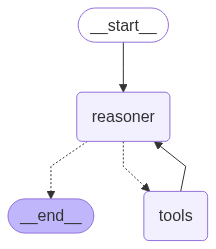

In [22]:
react_graph

In [26]:
messages=[HumanMessage(content="what is 2 times of narendramodi's age?")]


In [27]:
messages=react_graph.invoke({"messages":messages})

In [28]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 times of narendramodi's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_0vgx)
 Call ID: call_0vgx
  Args:
    query: narendra modi age
================================= Tool Message =================================
Name: duckduckgo_search

Narendra Modi is the 14th prime minister of India. His Hindu nationalist policies and some of his economic reforms have proved controversial to many within and outside India. ... September 17, 1950, Vadnagar, India (age 74) (Show more) Title / Office: prime minister (2014-), India (Show more) Political Affiliation: Bharatiya Janata Party ... List of all Prime Ministers of India till 2025: Narendra Modi is the current and 14th Prime Minister of India who assumed office on 10 June 2024. Jawaharlal Nehru is the first and the longest ... Learn about the life and achievements of Narendra M

In [29]:
messages=[HumanMessage(content="what is two times (3 + 2) ?")]


In [30]:
messages=react_graph.invoke({"messages":messages})

In [31]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is two times (3 + 2) ?
================================== Ai Message ==================================
Tool Calls:
  add (call_g471)
 Call ID: call_g471
  Args:
    a: 3
    b: 2
================================= Tool Message =================================
Name: add

5
================================== Ai Message ==================================
Tool Calls:
  multiply (call_8yy4)
 Call ID: call_8yy4
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiply

10
================================== Ai Message ==================================

10


In [32]:
%pip install yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.9/117.9 KB 821.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.4/117.4 KB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.6/181.6 KB 2.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 7.5 MB/s eta 0:00:0000:0100:01m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 6.6 MB/s eta 0:00:0000:01:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.2/446.2 KB 5.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 KB 1.4 MB/s eta 0:00:00a 0:00:01
  Created wheel for peewee: filename=peewee-3.18.1-py3-none-any.whl size=139052 sha256=2ef6fd5b408342842f40be4ed8de5fdef4091b43be18d6825c93b55b6e46b04e
  Stored in directory: /home/abhishek/.cache/pip/wheels/8d/c2/af/d591c26196f80ecdedb

In [33]:
import yfinance as yf

In [36]:
def get_stock_price(ticker: str) -> float:
    """
    Gets a stock price from Yahoo Finance.
    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock= yf.Ticker(ticker=ticker)
    return stock.info["previousClose"]

In [37]:
get_stock_price("AAPL")

203.27

In [56]:
a=" "
b="".join(filter(str.isalnum,a)).lower()
print(b)